In [1]:
print("hello")

hello


In [2]:
import cadquery as cq
from jupyter_cadquery import show
import numpy
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

Overwriting auto display for cadquery Workplane and Shape


In [3]:
import cadquery as cq
import math

def create_triangle_outline(part, outer_thickness=1):
    bbox = part.val().BoundingBox()
    slope = (bbox.zmax - bbox.zmin) / (bbox.xmax - bbox.xmin)
    intercept = bbox.zmax
    normal_shift = outer_thickness * math.sqrt(1 + slope**2)
    new_intercept = intercept - normal_shift

    def outline_line(x, return_z=True):
        if return_z:
            return slope * x + new_intercept
        else:
            return (x - new_intercept) / slope

    inner = (
        cq.Workplane("XZ")
        .polyline([
            (-outer_thickness, outer_thickness),
            (-outer_thickness, outline_line(-outer_thickness)),
            (outline_line(outer_thickness, return_z=False), outer_thickness)
        ])
        .close()
        .extrude(-(bbox.ymax - bbox.ymin))
    )

    hollow_triangle = part.cut(inner)
    inner_vol = max([f.Area() for f in part.faces().vals()]) * (bbox.ymax - bbox.ymin)

    return hollow_triangle, inner, inner_vol


In [4]:
def density_to_spacing(y, a, b, c):
    if (y - c) / a <= 0:
        raise ValueError("Invalid input")
    return (1 / b) * np.log((y - c) / a)

In [14]:
import cadquery as cq

def get_grid_infill(
    part,
    density=50,
    rod_diameter=0.45,
    spacing=0,
    outline_thickness=0.87,
    bed_width=50,
    bed_depth=50,
):
  

    
    outline, inner, inner_vol = create_triangle_outline(part, outer_thickness=outline_thickness)


    
    a, b, c = 65.530, 0.848, -1.580
    if spacing == 0:
        spacing = inverse_to_x(density, a, b, c)
    bed_width = math.ceil(70/spacing) * spacing
    bed_depth = bed_width
    com = part.val().Center()
    infill_thickness = (part.val().BoundingBox().ymax - part.val().BoundingBox().ymin)

    grid = cq.Workplane("XZ")

    x = -bed_width / 2
    while x <= bed_width / 2:
        grid = grid.union(
            cq.Workplane("XZ")
            .center(x, 0)
            .rect(rod_diameter, bed_depth)
            .extrude(-infill_thickness)
        )
        x += spacing

    z = -bed_depth / 2
    while z <= bed_depth / 2:
        grid = grid.union(
            cq.Workplane("XZ")
            .center(0, z)
            .rect(bed_width, rod_diameter)
            .extrude(-infill_thickness)
        )
        z += spacing
        
    bbox = part.val().BoundingBox()
    cz = (bbox.zmax + bbox.zmin) / 2
    cx = (bbox.xmax + bbox.xmin) / 2
    
    grid = grid.translate(((math.ceil(70/spacing) % 2) * (spacing/2), 0, ((math.ceil(70/spacing) % 2) * (spacing/2))))
    marker = cq.Workplane("XY").center(cx, com.y).workplane(offset=cz).sphere(0.5)
    grid = grid.rotate((0, 0, 0), (0, 1, 0), 45)

    grid = grid.translate((cx , 0, cz))
    infill_inside = grid.intersect(inner)
    
    result = outline.union(infill_inside)
    infill_volume = infill_inside.val().Volume()
    density_percent = infill_volume / inner_vol * 100
    return result, density_percent


In [21]:
def get_finray_infill(part, density = 25, spacing = 0, rod_diameter = 0.45, outline_thickness = 0.45):

    outline, inner, inner_vol = create_triangle_outline(part, outer_thickness=outline_thickness)
    
    a = 39.493
    b = 1.029
    c = 0.351

    if spacing == 0:
        spacing = inverse_to_x(density, a, b, c)
    
    bed_width = math.ceil(70/spacing) * spacing
    bed_depth = bed_width
    com = part.val().Center()
    print(math.ceil(70/spacing))
    infill_thickness = (part.val().BoundingBox().ymax - part.val().BoundingBox().ymin)
    grid = cq.Workplane("XZ")
    
    z = -bed_width / 2
    while z <= bed_width / 2:
        grid = grid.union(
            cq.Workplane("XZ")
            .center(0, z)
            .rect(bed_width, rod_diameter)
            .extrude(-infill_thickness)
        )
        z += spacing
        
    bbox = part.val().BoundingBox()
    cz = (bbox.zmax + bbox.zmin) / 2
    cx = (bbox.xmax + bbox.xmin) / 2
    grid = grid.translate((0, 0, ((math.ceil(70/spacing) % 2) * (spacing/2))))
    grid = grid.rotate((0, 0, 0), (0, 1, 0), 30)
    grid = grid.translate((cx , 0, cz))
    infill_inside = grid.intersect(inner)

    result = outline.union(infill_inside)
    infill_volume = infill_inside.val().Volume()
    
    
    return result, infill_volume/inner_vol * 100
    
    
    

In [42]:
import math

def get_triangle_infill(part, spacing = 0, density = 50, rod_diameter = 0.45, outline_thickness = 0.87):
    
    thickness = 20  

    outline, inner, inner_vol = create_triangle_outline(part, outer_thickness=outline_thickness)

    a = 89.731
    b = 0.760
    c = -4.124

    if (spacing == 0):
        spacing = inverse_to_x(density, a, b, c)
        
    width = (math.ceil(25/spacing) * spacing) * 2 
    depth = (math.ceil(25/spacing) * spacing) * 2  
    
    grid = cq.Workplane("XZ")
    
    x = -width/2
    while x <= width/2:
        grid = grid.union(
            cq.Workplane("XZ").center(x, 3)
            .rect(rod_diameter, depth) 
            .extrude(-thickness)         
        )
        x += spacing

    grid = grid.rotate((0, 0, 0), (0, 1, 0), -90)

    grid_tri_one = cq.Workplane("XZ")

    x = -width/2
    while x <= width/2:
        grid_tri_one = grid_tri_one.union(
            cq.Workplane("XZ").center(x, 3)
            .rect(rod_diameter, depth) 
            .extrude(-thickness)         
        )
        x += spacing
        
    grid_tri_one = grid_tri_one.rotate((0, 0, 0), (0, 1, 0), 30)

    grid_tri_two = cq.Workplane("XZ")

    x = -width/2
    while x <= width/2:
        grid_tri_two = grid_tri_two.union(
            cq.Workplane("XZ").center(x, 3)
            .rect(rod_diameter, depth) 
            .extrude(-thickness)         
        )
        x += spacing
        
    grid_tri_two = grid_tri_two.rotate((0, 0, 0), (0, 1, 0), -30)
    
    grid_tri = grid_tri_two.union(grid_tri_one)
    grid = grid.union(grid_tri)
    
    bbox = part.val().BoundingBox()
    cz = (bbox.zmax + bbox.zmin) / 2
    cx = (bbox.xmax + bbox.xmin) / 2
    
    grid = grid.rotate((0, 0, 0), (0, 1, 0), -45)

    grid = grid.translate((cx , 0, cz))

    infill_inside = grid.intersect(inner)

    result = outline.union(infill_inside)
    infill_volume = infill_inside.val().Volume()
    
    return result, infill_volume/inner_vol * 100

In [39]:
import numpy as np

def inverse_to_x(y, a, b, c):
    
    if (y - c) == 0:
        raise ValueError("Invalid input: division by zero (y cannot equal c).")
    if (a / (y - c)) <= 0:
        raise ValueError("Invalid input: (a / (y - c)) must be positive.")
    return (a / (y - c)) ** (1 / b)


In [40]:

def hexagon_func(side_length, thickness, cut=True):
    pts = []
    for i in range(6):
        angle = math.radians(60 * i)
        pts.append((math.cos(angle) * side_length,
                    math.sin(angle) * side_length))
    
    hexagon = cq.Workplane("XZ").polyline(pts + [pts[0]]).close().extrude(-10)
    hexagon = hexagon.rotate((0,0,0), (0, 1, 0), 30)
    if cut:
        hexagon = hexagon.cut(hexagon_func(side_length-thickness, thickness, cut=False))
        
    return hexagon
    

def get_honeycomb_infill(part, side_length = 0, density = 20, rod_diameter = 0.867, outline_thickness = 0.867):

    outline, inner, inner_vol = create_triangle_outline(part, outer_thickness=outline_thickness)
    a = 80.529
    b = 0.817
    c = -2.210

    if (side_length == 0):
        side_length = inverse_to_x(density, a, b, c)

    layers = 3
    thickness = 10
    grid = cq.Workplane("XZ")
    space = math.sin(math.pi/3) * side_length
    space_y = (side_length/2) + side_length
    width = 30

    z = 0
    for layer in range(layers):
        if layer % 2 == 1:
            x = -space+math.sin(math.pi/6) * rod_diameter
        else:
            x = 0
        
        while x <= width:
            
            grid = grid.union(hexagon_func(side_length, rod_diameter).
                    translate((x, 0,z)))
            
            x += space*2 - rod_diameter
                    
        if layer % 2 == 1:
            x = -space+math.sin(math.pi/6) * rod_diameter
        else:
            x = 0
            
        while x >= -width:
            
            grid = grid.union(hexagon_func(side_length, rod_diameter).
                    translate((x, 0,z)))
            
            x -= space*2 - rod_diameter
            
        z += -space_y+math.sin(math.pi/3) * rod_diameter
        

    z = 0
    for layer in range(layers):
        if layer % 2 == 1:
            x = -space+math.sin(math.pi/6) * rod_diameter
        else:
            x = 0
        
        while x <= width:
            
            grid = grid.union(hexagon_func(side_length, rod_diameter).
                    translate((x, 0,z)))
            
            x += space*2 - rod_diameter
            

        if layer % 2 == 1:
            x = -space+math.sin(math.pi/6) * rod_diameter
        else:
            x = 0
        
        while x >= -width:
            
            grid = grid.union(hexagon_func(side_length, rod_diameter).
                    translate((x, 0,z)))
            
            x -= space*2 - rod_diameter
            
        z -= -space_y+math.sin(math.pi/3) * rod_diameter



    
    bbox = part.val().BoundingBox()
    cz = (bbox.zmax + bbox.zmin) / 2
    cx = (bbox.xmax + bbox.xmin) / 2
    grid = grid.translate((0, 0, (-side_length+rod_diameter)/2))
    grid = grid.rotate((0, 0, 0), (0, 1, 0), -45)

    grid = grid.translate((cx , 0, cz))

    infill_inside = grid.intersect(inner)

    result = outline.union(infill_inside)
    infill_volume = infill_inside.val().Volume()
    return result, infill_volume/inner_vol * 100


In [41]:

part = cq.importers.importStep("STEP_files/GripperForOpt_v2.step")

infill_result, density = get_triangle_infill(
    part,
    density=10,
)
show(infill_result)
print(density)



+


CadViewerWidget(anchor=None, aspect_ratio=0.75, cad_width=800, control='trackball', glass=True, height=600, id…

9.872250097525006


In [35]:
xcoords, ycoords = [], []

for spacing in numpy.arange(1.5, 15.5, 0.5):
    infill, density = get_triangle_infill(part, spacing = spacing)
    xcoords.append(spacing)
    ycoords.append(density)



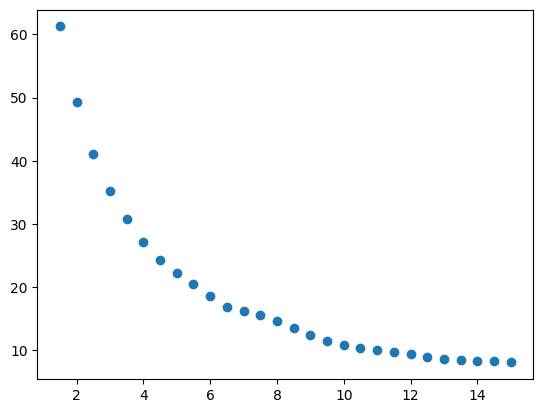

In [36]:
plt.scatter(xcoords, ycoords)


Inverse fit constants (a, b, c): [89.73062292  0.76007261 -4.12377974]

Inverse fit:   y = 89.731/x^0.760 + -4.124


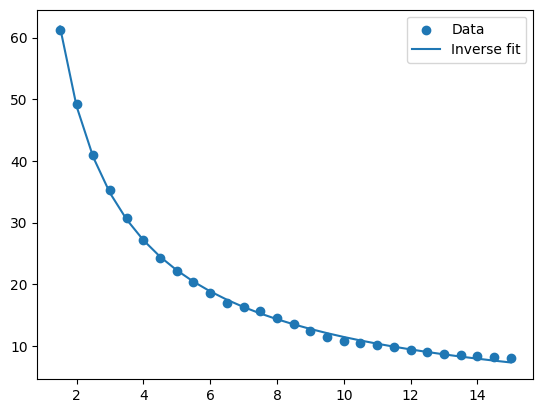

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = xcoords
y = ycoords

# Define model functions
def inverse(x, a, b, c): return a / (x**b) + c

# Fit models
params_inv, _ = curve_fit(inverse, x, y)

# Print the constants
print("Inverse fit constants (a, b, c):", params_inv)

# Optional: format them neatly
print(f"\nInverse fit:   y = {params_inv[0]:.3f}/x^{params_inv[1]:.3f} + {params_inv[2]:.3f}")


# Plot best visually
plt.scatter(x, y, label="Data")
plt.plot(x, inverse(x, *params_inv), label="Inverse fit")
plt.legend(); plt.show()